In [ ]:
Copy the code below into your code. Run the code. It should download and open a new dataset that has CO2 emissions for a field site in Barrow, Alaska (brw).

The code below will download your data into your working directory. You should be able to open it using the filename co2-emissions-barrow.csv.

# Download greenhouse gas CO2 data
import urllib.request

greenhouse_gas_url = "ftp://aftp.cmdl.noaa.gov/data/trace_gases/co2/in-situ/surface/brw/co2_brw_surface-insitu_1_ccgg_MonthlyData.txt"

urllib.request.urlretrieve(
    url=greenhouse_gas_url,
    filename="co2-emissions-barrow.csv"
)

Once you have downloaded the data:

- Read the data using pandas read_csv().
- The data has some additional rows of information stored as metadata. You will need to use the skiprows= parameter to skip those metadata     rows and properly import the data.
   HINT: remember when you use skiprows to consider 0-based indexing.
- the data columns are separated by blank spaces rather than commas so use sep=" " for pandas to understand the dataframe    
- Finally plot the data using pandas. Plot the "time_decimal" column on the x-axis and "value" on the y-axis.
What problem do you see in this plot? It seems that there some data that need to be removed before we can use the dataset. Usually, NOAA data contain data registered as -99.99, -999.99, etc. in this case use the following command to see you see any data

co2_df["value"].describe()
and play attention to the smallest data reported in thos column of the dataframe. Now, in order to remove this data use something like

co2_df["value"].min()
co2_df[co2_df["value"] < -???]
import numpy as np
co2_df.loc[co2_df["value"] < 0, "value"] = np.nan
Reemplace ??? by a number you consider appropriate. Once you finish, plot again the data. You should end up with a figure similar toEl problema que se observa en la primera gráfica es que el conjunto de datos contiene valores inválidos que representan datos faltantes. Los datos de NOAA suelen usar números negativos como -99.99 o -999.99 para indicar mediciones faltantes o incorrectas. Estos valores distorsionan la gráfica porque la concentración de CO₂ no puede ser negativa.



Al revisar las estadísticas de la columna value usando co2_df["value"].describe() y al identificar el valor mínimo con co2_df["value"].min(), se puede ver que existen valores irreales en el conjunto de datos. Por lo tanto, estos valores deben eliminarse o reemplazarse antes de analizar los datos.

Para solucionar este problema, todos los valores menores que cero se reemplazaron por NaN utilizando el siguiente comando:

In [ ]:
co2_df.loc[co2_df["value"] < 0, "value"] = np.nan

In [3]:
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# URL usando HTTPS en lugar de FTP
greenhouse_gas_url = "https://gml.noaa.gov/aftp/data/trace_gases/co2/in-situ/surface/brw/co2_brw_surface-insitu_1_ccgg_MonthlyData.txt"

urllib.request.urlretrieve(
    greenhouse_gas_url,
    "co2-emissions-barrow.csv"
)

# Leer el archivo
co2_df = pd.read_csv(
    "co2-emissions-barrow.csv",
    skiprows=151,
    sep=r"\s+"
)

# Revisar estadísticas
print(co2_df["value"].describe())

# Ver valores negativos
print(co2_df[co2_df["value"] < 0])

# Reemplazar valores inválidos
co2_df.loc[co2_df["value"] < 0, "value"] = np.nan

# Graficar
co2_df.plot(x="time_decimal", y="value", figsize=(10,5), legend=False)

plt.xlabel("Decimal Time")
plt.ylabel("CO2 concentration")
plt.title("CO2 Emissions - Barrow, Alaska")
plt.grid(True)

plt.show()

URLError: <urlopen error Tunnel connection failed: 403 Forbidden>

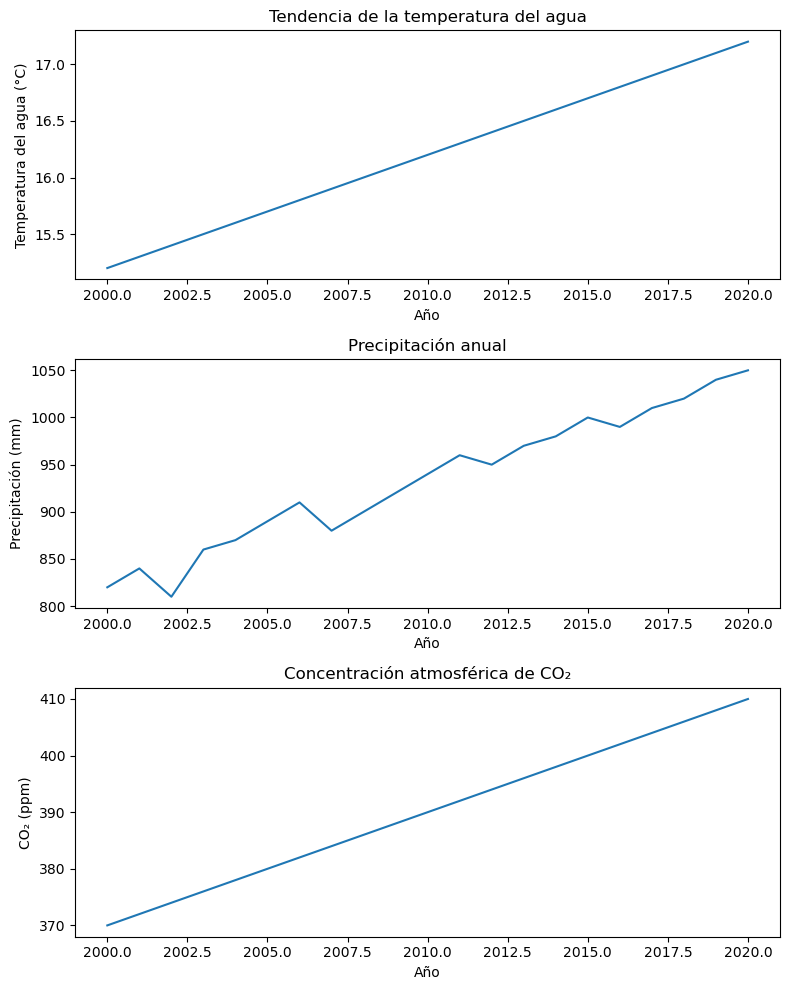

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Crear datos sintéticos
years = np.arange(2000, 2021)

water_temperature = [15.2,15.3,15.4,15.5,15.6,15.7,15.8,15.9,16.0,16.1,
                     16.2,16.3,16.4,16.5,16.6,16.7,16.8,16.9,17.0,17.1,17.2]

precipitation = [820,840,810,860,870,890,910,880,900,920,
                 940,960,950,970,980,1000,990,1010,1020,1040,1050]

co2 = [370,372,374,376,378,380,382,384,386,388,
       390,392,394,396,398,400,402,404,406,408,410]

# Crear figura y subplots
fig, axs = plt.subplots(3, 1, figsize=(8,10))

# Temperatura del agua
axs[0].plot(years, water_temperature)
axs[0].set_title("Tendencia de la temperatura del agua")
axs[0].set_xlabel("Año")
axs[0].set_ylabel("Temperatura del agua (°C)")

# Precipitación
axs[1].plot(years, precipitation)
axs[1].set_title("Precipitación anual")
axs[1].set_xlabel("Año")
axs[1].set_ylabel("Precipitación (mm)")

# CO2
axs[2].plot(years, co2)
axs[2].set_title("Concentración atmosférica de CO₂")
axs[2].set_xlabel("Año")
axs[2].set_ylabel("CO₂ (ppm)")

plt.tight_layout()
plt.show()

Las gráficas muestran la evolución de tres variables ambientales a lo largo del tiempo: temperatura del agua, precipitación anual y concentración atmosférica de CO₂. En el primer gráfico se observa un aumento gradual en la temperatura del agua, lo cual puede estar asociado con el calentamiento global y el incremento de la temperatura media del sistema climático.

La concentración de CO₂ también presenta una tendencia creciente, lo cual coincide con el aumento de emisiones de gases de efecto invernadero debido a actividades humanas como la quema de combustibles fósiles y la deforestación. Este incremento en CO₂ es uno de los principales factores que contribuyen al calentamiento del sistema climático.

Por otro lado, la precipitación muestra variabilidad interanual, aunque presenta una ligera tendencia creciente. Este comportamiento puede estar relacionado con cambios en el ciclo hidrológico, ya que el aumento de temperatura puede intensificar procesos de evaporación y precipitación en algunas regiones.